In [37]:
# Pacchetto per apertura dati salvati in cartelle zippate
import zipfile

# Pacchetti per analisi dati
#import xarray as xr
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import seaborn as sns
import warnings; warnings.simplefilter("ignore")
from functools import reduce
from sklearn.linear_model import LinearRegression
import math
import pytz

# Pacchetti per visualizzazioni grafiche
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import calendar
from collections import Counter

<span style="font-size: x-large;">**GESTIONE DATI**</span>  
  
  **<span style="font-size: large;">1. dati davis**

In [48]:
percorso = "./DATI_ORIGINALI/"

# Il percorso va cambiato in funzione di dove sono i vostri dati
nome_file = "Dati_Stazione.zip"
file= str(percorso)+str(nome_file)

with zipfile.ZipFile(file, 'r') as zip_ref:
    zip_ref.extractall(percorso)

stazioni = ["A","B","C"]

for stazione in stazioni:
    
    print("Stazione "+stazione)

    file = percorso+"Dati Meteo - Stazione "+stazione+".txt"
    
    # Di seguito si inizializza una lista vuota, all'interno della quale si va a caricare ogni linea della tabella ".txt".
    # In questo contesto, è importante notare che ogni colonna dei file è separata da spazi bianchi, che devono essere tenuti 
    # in considerazione al momento del caricamento dei dati.
    # Per farlo, si adopera "line.split()", che legge riga per riga la tabella ".txt" (compreso il nome delle colonne) ed 
    # elimina tutti gli spazi tra una colonna e l'altra.

    lista = []
    with open(file, encoding='ISO-8859-1') as f:
        for line in f:
            l = line.split()
            lista.append(l)
    
    # A questo punto, trasformiamo la lista in un DataFrame di pandas, con le colonne nominate come nel file originale.
    df = pd.DataFrame(lista[1:],columns=lista[0])
    
    # Seppur non necessario ai fini delle analisi, con i prossimi due comandi si sistemano le intestazioni delle colonne:
    # 1. Eliminiamo la virgola alla fine dei nomi delle diverse colonne nel file originale (es. "wndSpeed,")
    df.columns = df.columns.str.rstrip(',')    
    # 2. Eliminiamo il carattere "#" di fronte alla parola "Date" della prima colonna ("#Date")
    nome_prima_colonna = df.columns[0][1:]
    df.rename(columns={df.columns[0]: nome_prima_colonna}, inplace=True)
    
    # I dati della stazione C presentano dei caratteri verso la fine dell'intervallo temporale che non sono facilmente decifrati/interpretati da python.
    # Si procede quindi a selezionare solo quelle righe del dataframe della stazione C dove tutte le colonne contengono solo 
    # caratteri alfabetici (a-zA-Z), caratteri numerici (0-9) e il segno meno (-).
    
    if stazione == "C":
        for col in range(df.shape[1]):
            column = df.columns[col]
            mask = df[str(column)].str.contains(r'^[a-zA-Z0-9.-]+$', na=False)
            df = df[mask]
    else:
        pass

#creo colonna Datetime
    day = df['Date'].values; hour = df['Time'].values
    date_final = np.array([datetime.strptime(data + ' ' + ora, "%Y%m%d %H.%M") for data, ora in zip(day, hour)])
    df.insert(2,'Datetime',date_final)
    df.drop(df.columns[:2],axis=1, inplace=True)
            
    df.iloc[:, 1:] = df.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')
                    
#riordina by date
    df = df.sort_values(by='Datetime', ignore_index=True) #ricrea indici di riga da 0 a n-1
    df.set_index(df['Datetime'], inplace=True)
    df.index.name = None
    globals()["df_"+stazione] = df

Stazione A
Stazione B
Stazione C


In [49]:
df_A

,Datetime,Interval,Press,inTemp,outTemp,inHum,outHum,wndSpeed,wndDir,windGust,wGstDir,rainRate,rain,dewpoint,wdChill,heatIndx,ET,totRad,UV
2005-09-22 03:00:00,2005-09-22 03:00:00,30.0,1017.27,22.22,14.28,44.0,76.0,0.447,270.0,2.235,292.5,0.0,0.0,10.1,14.28,14.28,0.0,0.0,0.8
2005-09-22 03:30:00,2005-09-22 03:30:00,30.0,1017.21,22.11,14.11,45.0,76.0,0.447,270.0,3.129,270.0,0.0,0.0,9.94,14.11,14.11,0.0,0.0,0.8
2005-09-22 04:00:00,2005-09-22 04:00:00,30.0,1017.31,22.06,13.94,45.0,76.0,0.447,270.0,2.682,270.0,0.0,0.0,9.78,13.94,13.94,0.0,0.0,0.8
2005-09-22 04:30:00,2005-09-22 04:30:00,30.0,1017.27,21.94,13.94,45.0,76.0,0.0,270.0,1.788,270.0,0.0,0.0,9.78,13.94,13.94,0.0,0.0,0.8
2005-09-22 05:00:00,2005-09-22 05:00:00,30.0,1017.17,21.83,13.89,45.0,76.0,0.447,292.5,2.235,315.0,0.0,0.0,9.73,13.89,13.89,0.0,0.0,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-10-22 11:00:00,2019-10-22 11:00:00,30.0,1023.03,23.83,-73.28,63.0,-99.9,-44.655,-99.9,0.0,-99.9,0.0,0.0,-73.28,-73.28,-73.28,0.0,-99.9,-99.9
2019-10-22 11:30:00,2019-10-22 11:30:00,30.0,1023.07,23.89,-73.28,63.0,-99.9,-44.655,-99.9,0.0,-99.9,0.0,0.0,-73.28,-73.28,-73.28,0.0,-99.9,-99.9
2019-10-22 12:00:00,2019-10-22 12:00:00,30.0,1023.03,23.89,-73.28,63.0,-99.9,-44.655,-99.9,0.0,-99.9,0.0,0.0,-73.28,-73.28,-73.28,0.0,-99.9,-99.9
2019-10-22 12:30:00,2019-10-22 12:30:00,30.0,1022.83,23.89,-73.28,63.0,-99.9,-44.655,-99.9,0.0,-99.9,0.0,0.0,-73.28,-73.28,-73.28,0.0,-99.9,-99.9


**<span style="font-size: large;">Solo dati alle HH:00 o HH:30**

In [50]:
for stazione in stazioni:
    df = globals()["df_"+stazione].copy() #sono dati raw con colonna datetime unica e ordinata per datetime con nuovi indici
    
    globals()["df_"+stazione+"_interval30"] = df[((df.Datetime.dt.minute == 0)|(df.Datetime.dt.minute == 30))&(df.Interval == 30)]
    print(f"Stazione {stazione} " + str( globals()["df_"+stazione+"_interval30"].Interval.min())) #to verify


Stazione A 30.0
Stazione B 30.0
Stazione C 30.0


<span style="font-size: large;">**Filtro temporale Davis**<br>
Dal 2015 al 2016

In [51]:
def get_season(month):
    if 3 <= month <= 5:
        return 'MAM'
    elif 6 <= month <= 8:
        return 'JJA'
    elif 9 <= month <= 11:
        return 'SON'
    else:
        return 'DJF'

for stazione in stazioni:
    print("STAZIONE_"+stazione)
    df = globals()["df_"+stazione+"_interval30"].copy()  #sono dati raw con colonna datetime unica e ordinata per datetime con nuovi indici
    #aggiungo indice di stagione
    df['Stagione'] = df['Datetime'].dt.month.apply(get_season)
    #filtro anni di interesse
    df_year = df[(df["Datetime"].dt.year >= 2015)&(df["Datetime"].dt.year <= 2016)]
    globals()["df_"+stazione+"_year"] = df_year

    print("raw      " + str(globals()["df_"+stazione+"_interval30"].shape[0]))
    print("rimaste  " + str(globals()["df_"+stazione+"_year"].shape[0]))

STAZIONE_A
raw      192033
rimaste  35082
STAZIONE_B
raw      187243
rimaste  34947
STAZIONE_C
raw      85469
rimaste  35083


**<span style="font-size: large;">Dataframe ARPA** <br>
Temperatura, UR, press

In [52]:
percorso = "./DATI_ARPAE/"
files = ['tpavg', 'tpmax', 'tpmin', 'uravg', 'urmax', 'urmin', 'pressure']
for file in files:
    # Eliminiamo le prime 4 righe che sono dati testuali e gli ultimi valori dell'anno precedente
    df = pd.read_csv(percorso+'2015-2016_'+file+'_urbana.csv', encoding='ISO-8859-1',names=['Datetime UTC','Fine validità (UTC)',file],
                        skiprows=4,on_bad_lines='skip')
    # Eliminiamo inoltre le ultime righe che hanno solo dati testuali
    df = df[:-2]
    # Eliminiamo la colonna "Fine validità (UTC)" in quanto disponiamo dell'informazione sulla data già dalla prima colonna.
    # La seconda colonna ci sta solo ad indicare che le misure sono misure di vento orarie (come già noto dal sito web ARPAE).
    df.drop(df.columns[1],axis=1, inplace=True)

    # Trasformiamo la colonna tempo in formato Data Anno-Mese-Giorno ora:minuto (come fatto in precedenza)
    df['Datetime UTC'] = pd.to_datetime(df['Datetime UTC'])
    df[file] = df[file].astype(float) #tofloat

    #converti to local time
    local_timezone = pytz.timezone('Etc/GMT-2')
    df['Datetime'] = df['Datetime UTC'].dt.tz_convert(local_timezone)
    df['Datetime'] = df['Datetime'].dt.tz_localize(None)
    df.set_index(df['Datetime'], inplace=True)
    df.index.name = None
    df.drop(df.columns[0], axis=1, inplace=True)
    #print(str(df.Datetime.min()) + " " + str(df.Datetime.max()))
    #print(df.columns)
    if file == files[0]:
        df_ARPAE = df
    else:
        df_ARPAE = pd.merge(df_ARPAE, df, on='Datetime', suffixes=(None, '_'+file))
df_ARPAE.set_index(df_ARPAE['Datetime'], inplace=True)
df_ARPAE.index.name = None
df_ARPAE.pressure = df_ARPAE.pressure / 100
df_ARPAE

,tpavg,Datetime,tpmax,tpmin,uravg,urmax,urmin,pressure
2015-01-01 01:00:00,-1.6,2015-01-01 01:00:00,-1.5,-1.7,72.0,76.0,70.0,1025.3
2015-01-01 02:00:00,-1.6,2015-01-01 02:00:00,-1.5,-1.8,73.0,79.0,70.0,1025.5
2015-01-01 03:00:00,-1.8,2015-01-01 03:00:00,-1.7,-1.9,80.0,82.0,78.0,1025.9
2015-01-01 04:00:00,-1.8,2015-01-01 04:00:00,-1.7,-1.9,77.0,80.0,71.0,1025.9
2015-01-01 05:00:00,-1.7,2015-01-01 05:00:00,-1.5,-1.9,68.0,72.0,64.0,1025.4
...,...,...,...,...,...,...,...,...
2016-12-31 21:00:00,2.5,2016-12-31 21:00:00,2.8,2.2,70.0,70.0,69.0,1021.1
2016-12-31 22:00:00,2.3,2016-12-31 22:00:00,2.5,2.2,68.0,69.0,65.0,1020.6
2016-12-31 23:00:00,2.1,2016-12-31 23:00:00,2.3,1.9,65.0,66.0,63.0,1020.4
2017-01-01 00:00:00,1.8,2017-01-01 00:00:00,2.0,1.5,62.0,65.0,60.0,1019.9


<span style="font-size: x-large;">**ANALISI DELLA TEMPERATURA**<span style="font-size: x-large;">  

<span style="font-size: large;">**1. Filtro di plausibilità**

In [53]:
tpmax = df_ARPAE.tpmax.max()
tpmin = df_ARPAE.tpmin.min()
urmax = df_ARPAE.urmax.max()
urmin = df_ARPAE.urmin.min()
prmax = df_ARPAE.pressure.max()
prmin = df_ARPAE.pressure.min()
tpmax, tpmin, urmin, urmax, prmax, prmin

(np.float64(37.5),
 np.float64(-3.0),
 np.float64(10.0),
 np.float64(103.0),
 np.float64(1030.1),
 np.float64(967.2))

In [54]:
for stazione in stazioni:
    df = globals()["df_"+stazione+"_year"]
    print(df.shape[0])
    globals()["df_"+stazione+"_year_filt"] = df[(df.outHum <= 100) & (df.outHum >= urmin) & 
                                           (df.outTemp >= tpmin) & (df.outTemp <= tpmax) & 
                                           (df.Press >= prmin) & (df.Press <= prmax)]
    print(globals()["df_"+stazione+"_year_filt"].shape[0] / df.shape[0])

35082
0.9358645459209851
34947
0.8659112370160529
35083
0.9518570247698316


  <span style="font-size: large;">**2. Risoluzione variabili**  

In [45]:
for stazione in stazioni:
    print("stazione "+stazione)
    df = globals()["df_"+stazione+"_year_filt"]
    vars = ['outTemp', 'outHum', 'Press']
    for var in vars:
        col = df[var].copy() #filtro anni, risoluzione temp, plausibilita
        col = col.drop_duplicates()
        col = col.sort_values()
        #print(col)
        differences_col = np.diff(col)  # Compute consecutive differences
        #print(differences_col)
        resolution_col = np.min(differences_col) if len(differences_col) > 0 else None
        print(f"{var} Resolution: {resolution_col} units")

stazione A
outTemp Resolution: 0.04999999999999716 units
outHum Resolution: 1.0 units
Press Resolution: 0.029999999999972715 units
stazione B
outTemp Resolution: 0.04999999999999716 units
outHum Resolution: 1.0 units
Press Resolution: 0.029999999999972715 units
stazione C
outTemp Resolution: 0.04999999999999716 units
outHum Resolution: 1.0 units
Press Resolution: 0.029999999999972715 units


<span style="font-size: large;">**3. CONFRONTO TRA STAZIONI DIVERSE**  

Per confrontare i dati di due stazioni, si possono adoperare diversi indici statistici, quali ad esempio:
- Indice di correlazione,
- Mean Error (ME),
- Mean Absolute Error (MAE),
- Root Mean Square Error (RMSE),
- RMSE normalizzato con la media del dataset di riferimento,

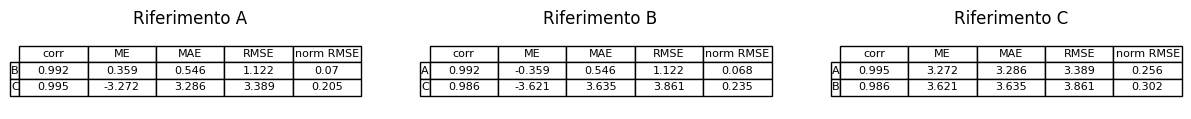

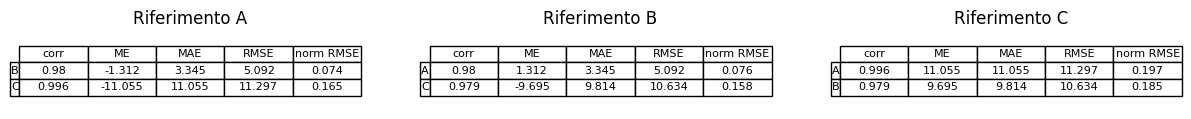

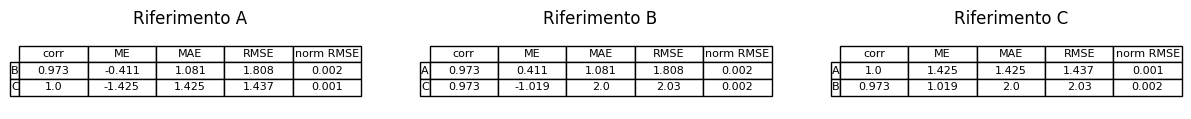

In [ ]:
import pandas as pd
import numpy as np

def statistics(var,ref):
    
    CORR = var.corrwith(ref)[0]
    ME = np.mean(np.subtract(var, ref))
    MAE = np.mean(np.abs(np.subtract(var, ref)))
    RMSE = np.sqrt(np.nanmean(np.square(np.subtract(var, ref))))
    nRMSE = RMSE / np.nanmean(ref)
    
    return CORR, ME, MAE, RMSE, nRMSE

def compare_column(ref, var, column_name):
    df = ref.copy()
    df_comp = var.copy()

    #seleziono dove stessa data
    common_index = list((df.index).intersection(df_comp.index))

    df_ref = df.loc[common_index].copy()
    df_to_comp = df_comp.loc[common_index].copy()
    corr,me,mae,rmse,nrmse = statistics(df_to_comp[[column_name]],df_ref[[column_name]])
    return corr,me,mae,rmse,nrmse

stazioni = ['A', 'B', 'C']
vars = ['outTemp', 'outHum', 'Press']
for var in vars:
    fig, axes = plt.subplots(1, 3, figsize=(3 * 5, 1))
    i = 0
    for riferimento in stazioni:
        rows = []
        #print("Riferimento "+riferimento)
        indexes = []
        for stazione in stazioni:
            if stazione != riferimento:
                indexes.append(stazione)
                corr, me, mae, rmse, nrmse = compare_column(globals()["df_"+riferimento+"_year_filt"], globals()["df_"+stazione+"_year_filt"], var)
                rows.append([round(corr,3), round(me,3), round(mae,3), round(rmse,3), round(nrmse,3)])

        df = pd.DataFrame(rows, index=indexes, columns=['corr', 'ME', 'MAE', 'RMSE', 'norm RMSE'])
        #display(df)

        ax = axes[i]
        i +=1
        ax.axis('off')
        ax.set_title("Riferimento "+riferimento, loc='center')
        table = pd.plotting.table(ax, df, loc='center', cellLoc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(8)
        table.scale(1, 1)
    plt.savefig('FIGURE/'+var+'_compare_davis.png', dpi=300, bbox_inches='tight')


4. CONFRONTO DIFFERENZE NEL TEMPO DELLE STAZIONI

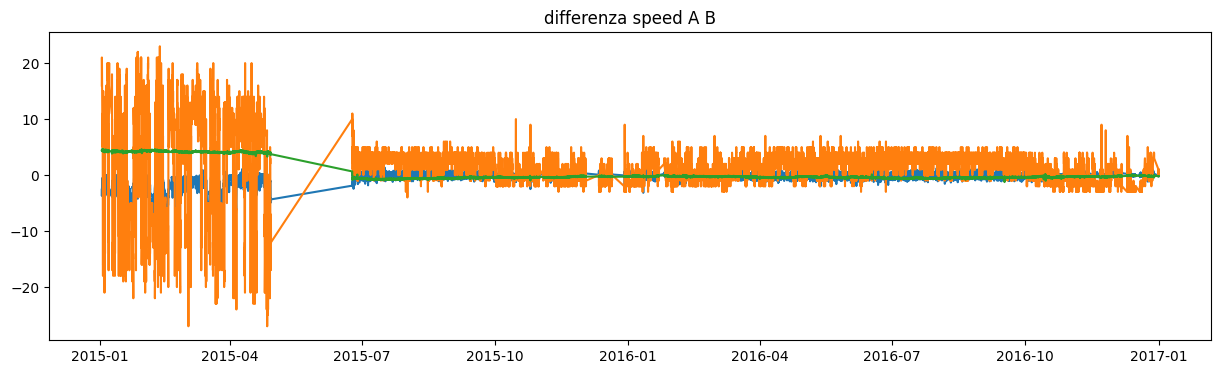

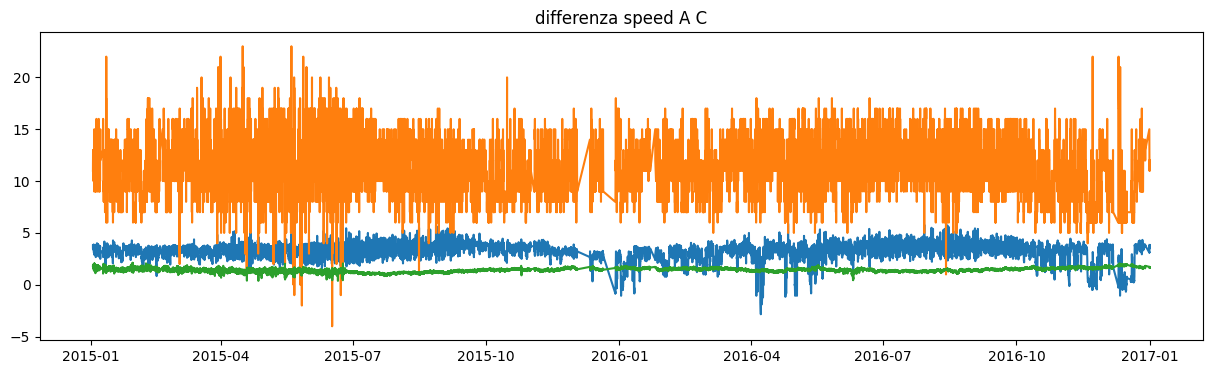

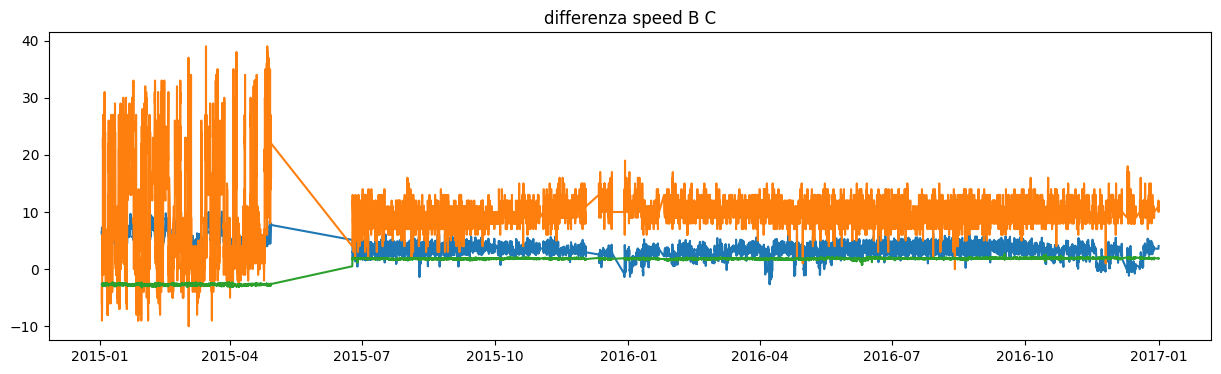

In [86]:
A = globals()["df_A_year_filt"]
B = globals()["df_B_year_filt"]
C = globals()["df_C_year_filt"]

vars = ['outTemp', 'outHum', 'Press']
for var in vars:
    df_merged = pd.merge(A, B, on='Datetime', suffixes=('_A', '_B'))
    plt.figure(1, figsize=(15, 4))
    plt.plot(df_merged["Datetime"], np.subtract(df_merged[var+"_A"], df_merged[var+"_B"]))
    plt.title("differenza speed A B")

    df_merged = pd.merge(A, C, on='Datetime', suffixes=('_A', '_C'))
    plt.figure(2, figsize=(15, 4))
    plt.plot(df_merged["Datetime"], np.subtract(df_merged[var+"_A"], df_merged[var+"_C"]))
    plt.title("differenza speed A C")

    df_merged = pd.merge(B, C, on='Datetime', suffixes=('_B', '_C'))
    plt.figure(3, figsize=(15, 4))
    plt.plot(df_merged["Datetime"], np.subtract(df_merged[var+"_B"], df_merged[var+"_C"]))
    plt.title("differenza speed B C")


<span style="font-size: large;">**DATI ARPAE**  
    
I dati delle stazioni della rete regionale ARPAE sono scaricabili liberamente dalla piattaforma dext3r (https://simc.arpae.it/dext3r/) selezionando il periodo e le variabili prescelte.

INTESITÀ

In [35]:
percorso = "./DATI_ARPAE/"
file = '2015-2016-speed1h.csv'

# Eliminiamo le prime 4 righe che sono dati testuali e gli ultimi valori dell'anno precedente
df = pd.read_csv(percorso+file, encoding='ISO-8859-1',names=['Datetime UTC','Fine validità (UTC)','wndSpeed'],
                    skiprows=4,on_bad_lines='skip')
# Eliminiamo inoltre le ultime righe che hanno solo dati testuali
df = df[:-7]
# Eliminiamo la colonna "Fine validità (UTC)" in quanto disponiamo dell'informazione sulla data già dalla prima colonna.
# La seconda colonna ci sta solo ad indicare che le misure sono misure di vento orarie (come già noto dal sito web ARPAE).
df.drop(df.columns[1],axis=1, inplace=True)

# Trasformiamo la colonna tempo in formato Data Anno-Mese-Giorno ora:minuto (come fatto in precedenza)
df['Datetime UTC'] = pd.to_datetime(df['Datetime UTC'])
df['wndSpeed'] = df.wndSpeed.astype(float) #tofloat

#converti to local time
local_timezone = pytz.timezone('Etc/GMT-2')
df['Datetime'] = df['Datetime UTC'].dt.tz_convert(local_timezone)
df['Datetime'] = df['Datetime'].dt.tz_localize(None)
df.set_index(df['Datetime'], inplace=True)
df.index.name = None

df_ARPAE_speed = df

print("arpa max " + str(df_ARPAE_speed["wndSpeed"].max()) )
print("arpa min " + str(df_ARPAE_speed["wndSpeed"].min()) )

df

arpa max 10.4
arpa min 0.0


,Datetime UTC,wndSpeed,Datetime
2015-01-01 00:00:00,2014-12-31 22:00:00+00:00,3.4,2015-01-01 00:00:00
2015-01-01 01:00:00,2014-12-31 23:00:00+00:00,3.4,2015-01-01 01:00:00
2015-01-01 02:00:00,2015-01-01 00:00:00+00:00,3.7,2015-01-01 02:00:00
2015-01-01 03:00:00,2015-01-01 01:00:00+00:00,3.9,2015-01-01 03:00:00
2015-01-01 04:00:00,2015-01-01 02:00:00+00:00,3.8,2015-01-01 04:00:00
...,...,...,...
2016-12-31 16:00:00,2016-12-31 14:00:00+00:00,1.0,2016-12-31 16:00:00
2016-12-31 17:00:00,2016-12-31 15:00:00+00:00,1.0,2016-12-31 17:00:00
2016-12-31 18:00:00,2016-12-31 16:00:00+00:00,0.9,2016-12-31 18:00:00
2016-12-31 19:00:00,2016-12-31 17:00:00+00:00,1.6,2016-12-31 19:00:00


DIREZIONE

In [36]:
percorso = "./DATI_ARPAE/"
file = '2015-2016-dir1h.csv'

# Eliminiamo le prime 4 righe che sono dati testuali e gli ultimi valori dell'anno precedente
df = pd.read_csv(percorso+file, encoding='ISO-8859-1',names=['Datetime UTC','Fine validità (UTC)','wndDir'],
                    skiprows=4,on_bad_lines='skip')
# Eliminiamo inoltre le ultime righe che hanno solo dati testuali
df = df[:-7]
# Eliminiamo la colonna "Fine validità (UTC)" in quanto disponiamo dell'informazione sulla data già dalla prima colonna.
# La seconda colonna ci sta solo ad indicare che le misure sono misure di vento orarie (come già noto dal sito web ARPAE).
df.drop(df.columns[1],axis=1, inplace=True)

# Trasformiamo la colonna tempo in formato Data Anno-Mese-Giorno ora:minuto (come fatto in precedenza)
df['Datetime UTC'] = pd.to_datetime(df['Datetime UTC'])
df['wndDir'] = df.wndDir.astype(float) #tofloat

#converti to local time
local_timezone = pytz.timezone('Etc/GMT-2')
df['Datetime'] = df['Datetime UTC'].dt.tz_convert(local_timezone)
df['Datetime'] = df['Datetime'].dt.tz_localize(None)
df.set_index(df['Datetime'], inplace=True)
df.index.name = None

#replace 360 with 0
df.wndDir = df.wndDir.replace(360.0, 0.0)

df_ARPAE_dir = df

print("arpa max " + str(df_ARPAE_dir["wndDir"].max()) )
print("arpa min " + str(df_ARPAE_dir["wndDir"].min()) )

df

arpa max 359.0
arpa min 0.0


,Datetime UTC,wndDir,Datetime
2015-01-01 00:00:00,2014-12-31 22:00:00+00:00,256.0,2015-01-01 00:00:00
2015-01-01 01:00:00,2014-12-31 23:00:00+00:00,257.0,2015-01-01 01:00:00
2015-01-01 02:00:00,2015-01-01 00:00:00+00:00,256.0,2015-01-01 02:00:00
2015-01-01 03:00:00,2015-01-01 01:00:00+00:00,253.0,2015-01-01 03:00:00
2015-01-01 04:00:00,2015-01-01 02:00:00+00:00,254.0,2015-01-01 04:00:00
...,...,...,...
2016-12-31 16:00:00,2016-12-31 14:00:00+00:00,332.0,2016-12-31 16:00:00
2016-12-31 17:00:00,2016-12-31 15:00:00+00:00,331.0,2016-12-31 17:00:00
2016-12-31 18:00:00,2016-12-31 16:00:00+00:00,213.0,2016-12-31 18:00:00
2016-12-31 19:00:00,2016-12-31 17:00:00+00:00,213.0,2016-12-31 19:00:00


MERGE IN ONE DATAFRAME ARPAE WIND

In [37]:
df_ARPAE = pd.merge(df_ARPAE_speed, df_ARPAE_dir, on='Datetime', suffixes=('_speed', '_dir'))
df_ARPAE.set_index(df_ARPAE['Datetime'], inplace=True)
df_ARPAE.index.name = None
df_ARPAE

,Datetime UTC_speed,wndSpeed,Datetime,Datetime UTC_dir,wndDir
2015-01-01 00:00:00,2014-12-31 22:00:00+00:00,3.4,2015-01-01 00:00:00,2014-12-31 22:00:00+00:00,256.0
2015-01-01 01:00:00,2014-12-31 23:00:00+00:00,3.4,2015-01-01 01:00:00,2014-12-31 23:00:00+00:00,257.0
2015-01-01 02:00:00,2015-01-01 00:00:00+00:00,3.7,2015-01-01 02:00:00,2015-01-01 00:00:00+00:00,256.0
2015-01-01 03:00:00,2015-01-01 01:00:00+00:00,3.9,2015-01-01 03:00:00,2015-01-01 01:00:00+00:00,253.0
2015-01-01 04:00:00,2015-01-01 02:00:00+00:00,3.8,2015-01-01 04:00:00,2015-01-01 02:00:00+00:00,254.0
...,...,...,...,...,...
2016-12-31 16:00:00,2016-12-31 14:00:00+00:00,1.0,2016-12-31 16:00:00,2016-12-31 14:00:00+00:00,332.0
2016-12-31 17:00:00,2016-12-31 15:00:00+00:00,1.0,2016-12-31 17:00:00,2016-12-31 15:00:00+00:00,331.0
2016-12-31 18:00:00,2016-12-31 16:00:00+00:00,0.9,2016-12-31 18:00:00,2016-12-31 16:00:00+00:00,213.0
2016-12-31 19:00:00,2016-12-31 17:00:00+00:00,1.6,2016-12-31 19:00:00,2016-12-31 17:00:00+00:00,213.0


ROSA VENTI ARPAW BOLOGNA URBANA

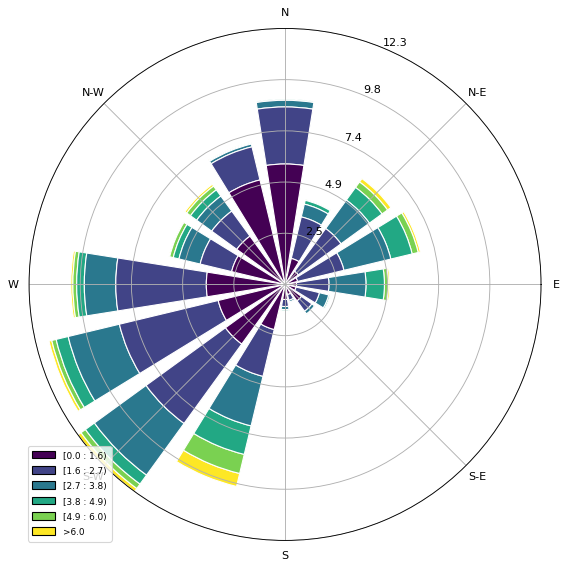

In [38]:
from windrose import WindroseAxes
ax = WindroseAxes.from_ax()
ax.bar(df_ARPAE.wndDir, df_ARPAE.wndSpeed, normed=True, opening=0.8, edgecolor="white", bins=[0.0, 1.6, 2.7, 3.8, 4.9, 6.0])
ax.set_legend()

plt.Figure(figsize=(8,8))
plt.savefig('FIGURE/windrose_arpae.png', dpi=300, bbox_inches='tight')

"Datetime" è fornito nella scalata temporale Coordinated Universal Time (UTC), mentre le stazioni Davis di UniBo sono in ora locale (timezone CET). Dobbiamo quindi convertire le stazioni Davis di UniBo nel formato UTC, al fine di rendere paragonabili le misure.  

Per farlo, adoperiamo il pacchetto Python *"pytz"*.

CONFRONTO CON ARPAE

In [39]:
globals()["df_"+stazione+"_year_interval30_good"].columns

Index(['Datetime', 'Interval', 'Press', 'diff3h_backward', 'diff3h_forward',
       'diff_backward', 'diff_foreward', 'inTemp', 'outTemp', 'inHum',
       'outHum', 'wndSpeed', 'wndDir', 'windGust', 'wGstDir', 'rainRate',
       'rain', 'dewpoint', 'wdChill', 'heatIndx', 'ET', 'totRad', 'UV',
       'Stagione'],
      dtype='object')

MEDIO STAZIONI DAVIS IN 1 ORA

In [40]:
for stazione in stazioni:
    df = globals()["df_"+stazione+"_year_interval30_good"]
    df['hour'] = df['Datetime'].dt.floor('H') #arrotondo ora precedente
    df['Datetime'] = df['hour']
    globals()["df_"+stazione+"_year_1h"] = df.drop('Stagione', axis=1).groupby('hour').mean()
    display(globals()["df_"+stazione+"_year_1h"])

,Datetime,Interval,Press,diff3h_backward,diff3h_forward,diff_backward,diff_foreward,inTemp,outTemp,inHum,...,windGust,wGstDir,rainRate,rain,dewpoint,wdChill,heatIndx,ET,totRad,UV
hour,,,,,,,,,,,,,,,,,,,,,
2015-01-01 05:00:00,2015-01-01 05:00:00,30.0,1034.44,2.5,-3.0,22.5,45.00,15.11,-1.11,32.0,...,3.129,247.5,0.0,0.0,-5.88,-1.11,-1.11,0.03,0.0,0.0
2015-01-01 06:00:00,2015-01-01 06:00:00,30.0,1034.17,3.0,-2.5,22.5,22.50,15.06,-0.56,32.0,...,3.129,247.5,0.0,0.0,-4.97,-0.56,-0.56,0.0,0.0,0.0
2015-01-01 07:00:00,2015-01-01 07:00:00,30.0,1034.34,3.0,-3.0,45.0,22.50,15.085,0.305,31.0,...,3.129,258.75,0.0,0.0,-4.325,0.305,0.305,0.015,0.0,0.0
2015-01-01 08:00:00,2015-01-01 08:00:00,30.0,1034.7,3.0,-3.5,45.0,56.25,15.275,0.555,30.5,...,3.3525,247.5,0.0,0.0,-4.37,0.555,0.555,0.0,8.0,0.0
2015-01-01 09:00:00,2015-01-01 09:00:00,30.0,1035.31,2.5,-3.5,22.5,45.00,15.47,1.305,30.0,...,3.129,258.75,0.0,0.0,-4.245,1.305,1.305,0.015,84.5,0.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-31 13:00:00,2016-12-31 13:00:00,30.0,1031.495,3.5,-3.0,90.0,67.50,20.11,7.275,28.0,...,3.3525,281.25,0.0,0.0,0.92,7.275,7.275,0.075,312.0,1.05
2016-12-31 14:00:00,2016-12-31 14:00:00,30.0,1030.77,2.5,-3.0,45.0,67.50,20.14,7.92,28.0,...,2.682,270.0,0.0,0.0,1.2,7.92,7.92,0.075,263.5,0.85
2016-12-31 15:00:00,2016-12-31 15:00:00,30.0,1030.31,3.0,NaN,45.0,NaN,20.22,8.61,28.0,...,2.235,270.0,0.0,0.0,1.05,8.61,8.61,0.0,143.0,0.3


,Datetime,Interval,Press,diff3h_backward,diff3h_forward,diff_backward,diff_foreward,inTemp,outTemp,inHum,...,windGust,wGstDir,rainRate,rain,dewpoint,wdChill,heatIndx,ET,totRad,UV
hour,,,,,,,,,,,,,,,,,,,,,
2015-01-01 00:00:00,2015-01-01 00:00:00,30.0,1030.415,NaN,-2.50,NaN,33.75,15.805,0.195,24.0,...,5.5875,258.75,0.0,0.0,-5.5,-1.955,0.195,0.015,0.0,1.0
2015-01-01 01:00:00,2015-01-01 01:00:00,30.0,1030.585,NaN,-2.50,NaN,45.00,15.695,0.17,24.0,...,6.258,281.25,0.0,0.0,-5.14,-2.265,0.17,0.015,0.0,1.0
2015-01-01 02:00:00,2015-01-01 02:00:00,30.0,1030.99,2.50,-2.50,45.00,45.00,15.53,-0.25,24.5,...,7.8225,281.25,0.0,0.0,-4.155,-2.75,-0.25,0.015,0.0,1.0
2015-01-01 03:00:00,2015-01-01 03:00:00,30.0,1030.855,2.50,-2.75,33.75,45.00,15.415,-0.415,25.0,...,7.599,281.25,0.0,0.0,-3.615,-3.225,-0.415,0.015,0.0,1.0
2015-01-01 04:00:00,2015-01-01 04:00:00,30.0,1030.345,2.50,-3.00,45.00,22.50,15.275,-0.195,25.0,...,5.811,303.75,0.0,0.0,-5.295,-2.685,-0.195,0.015,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-31 17:00:00,2016-12-31 17:00:00,30.0,1030.21,2.50,-6.00,315.00,270.00,20.94,6.44,28.0,...,3.576,0.0,0.0,0.0,0.97,6.44,6.44,0.03,6.0,0.0
2016-12-31 19:00:00,2016-12-31 19:00:00,30.0,1030.24,4.00,-4.50,270.00,67.50,20.94,5.06,29.0,...,1.788,270.0,0.0,0.0,0.81,5.06,5.06,0.03,0.0,0.0
2016-12-31 21:00:00,2016-12-31 21:00:00,30.0,1029.7,6.00,NaN,270.00,NaN,20.94,3.83,29.0,...,1.341,270.0,0.0,0.0,0.18,3.83,3.83,0.0,0.0,0.0


,Datetime,Interval,Press,diff3h_backward,diff3h_forward,diff_backward,diff_foreward,inTemp,outTemp,inHum,...,windGust,wGstDir,rainRate,rain,dewpoint,wdChill,heatIndx,ET,totRad,UV
hour,,,,,,,,,,,,,,,,,,,,,
2015-01-01 00:00:00,2015-01-01 00:00:00,30.0,1032.99,NaN,-2.50,NaN,22.5,15.25,-4.5,32.0,...,4.023,157.5,0.0,0.0,-10.47,-4.5,-4.5,0.0,0.0,0.9
2015-01-01 01:00:00,2015-01-01 01:00:00,30.0,1033.275,NaN,-2.50,NaN,22.5,15.14,-4.64,32.0,...,5.1405,292.5,0.0,0.0,-10.595,-4.64,-4.64,0.0,0.0,0.9
2015-01-01 02:00:00,2015-01-01 02:00:00,30.0,1033.595,2.5,-2.50,22.5,22.5,14.97,-4.805,32.5,...,5.5875,270.0,0.0,0.0,-9.61,-6.27,-4.805,0.015,0.0,0.9
2015-01-01 03:00:00,2015-01-01 03:00:00,30.0,1033.515,2.5,-5.75,22.5,45.0,14.885,-4.97,33.0,...,5.1405,303.75,0.0,0.0,-9.77,-6.445,-4.97,0.0,0.0,0.9
2015-01-01 04:00:00,2015-01-01 04:00:00,30.0,1032.92,2.5,-7.50,22.5,45.0,14.78,-4.86,33.0,...,4.47,281.25,0.0,0.0,-10.91,-4.86,-4.86,0.0,0.0,0.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-29 05:00:00,2016-12-29 05:00:00,30.0,1032.38,8.0,-6.00,157.5,0.0,20.39,1.44,31.0,...,3.576,112.5,0.0,0.0,-3.81,1.44,1.44,0.03,0.0,0.9
2016-12-29 15:00:00,2016-12-29 15:00:00,30.0,1035.97,4.0,NaN,0.0,NaN,20.56,4.11,30.0,...,4.47,112.5,0.0,0.0,-7.96,4.11,4.11,0.0,51.0,1.1
2016-12-29 16:00:00,2016-12-29 16:00:00,30.0,1036.0,4.0,NaN,0.0,NaN,20.56,3.94,29.0,...,3.129,135.0,0.0,0.0,-8.42,3.94,3.94,0.05,54.0,1.0


max ARPAE 10.4
max ARPAE 0.0


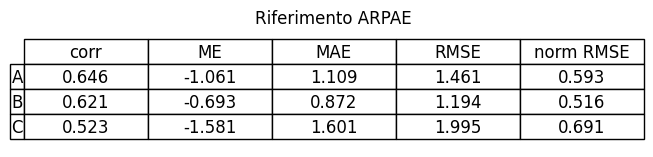

In [41]:
rows = []
for stazione in stazioni:
    corr, me, mae, rmse, nrmse = compare_column(globals()["df_ARPAE"], globals()["df_"+stazione+"_year_1h"], 'wndSpeed')
    rows.append([round(corr,3), round(me,3), round(mae,3), round(rmse,3), round(nrmse,3)])

df = pd.DataFrame(rows, index=stazioni, columns=['corr', 'ME', 'MAE', 'RMSE', 'norm RMSE'])
table = pd.plotting.table(ax, df, loc='center', cellLoc='center')

#table image from dataframe
fix, ax = plt.subplots(figsize=(4,1.5))
ax.axis('off')
ax.set_title("Riferimento ARPAE", loc='center')
table = pd.plotting.table(ax, df, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(2, 1.5)
plt.savefig('FIGURE/speed_compare_arpae.png', dpi=300, bbox_inches='tight')

print("max ARPAE "+ str(globals()["df_ARPAE"]['wndSpeed'].max()))
print("max ARPAE "+ str(globals()["df_ARPAE"]['wndSpeed'].min()))

A questo punto, possiamo confrontare la stazione A con la stazione ARPAE, facendo attenzione a garantire la corrispondenza temporale dei due datasets.  

A titolo di esempio, si riporta il grafico a dispersione dell'intensità del vento per le due stazioni.

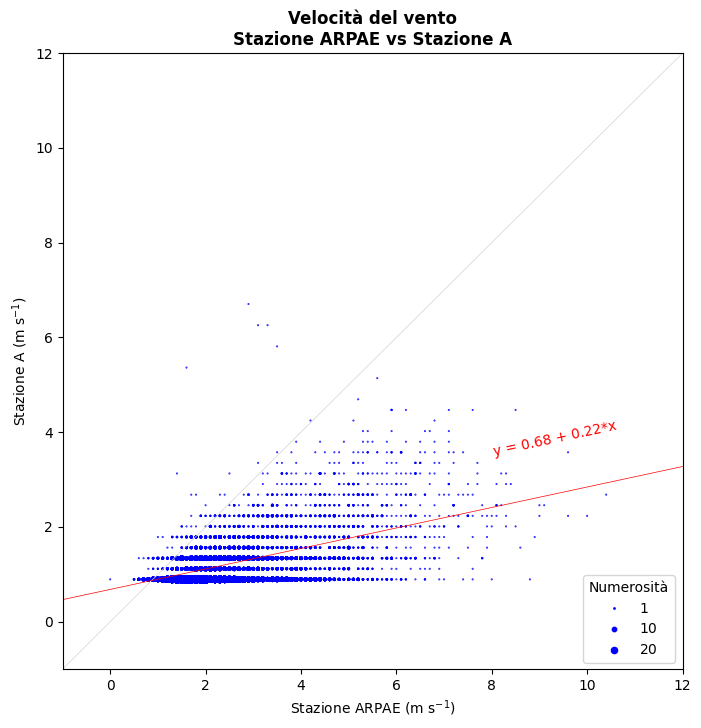

In [42]:
df_A = globals()["df_"+stazione+"_year_1h"][['Datetime','wndSpeed']]
df_merged = pd.merge(df_A, df_ARPAE, on='Datetime', suffixes=('_A', '_ARPAE'))
#display(df_merged)
df_merged = df_merged.dropna()

# Regressione Lineare
model = LinearRegression()
model.fit(df_merged['wndSpeed_ARPAE'].to_numpy().reshape((-1, 1)),df_merged['wndSpeed_A'].to_numpy())
intercept = model.intercept_
slope = model.coef_[0]

# Definizione delle grandezze dei marker, in funzione della numerosità
c = Counter(zip(df_merged['wndSpeed_ARPAE'],df_merged['wndSpeed_A']))
s = [0.2*c[(xx,yy)] for xx,yy in zip(df_merged['wndSpeed_ARPAE'],df_merged['wndSpeed_A'])]

fig, ax = plt.subplots(figsize=(8,8))

# Linea diagonale, che rappresenta una relazione lineare tra le due stazioni
ax.axline((1, 1), slope=1, color='lightgrey',linewidth=0.5)
ax.axline((0, intercept), slope=slope, color='red',linewidth=0.5) 

scatter_plot = plt.scatter(df_merged['wndSpeed_ARPAE'],df_merged['wndSpeed_A'],s=s,color='blue',label='Numero di occorrenze')

plt.xlabel('Stazione ARPAE (m s$^{-1}$)')
plt.ylabel('Stazione A (m s$^{-1}$)')
plt.xlim(-1,12)
plt.ylim(-1,12)

ax.legend(*scatter_plot.legend_elements(prop="sizes", num=[1,10,20,30,60],color='blue'), loc=(0.84,0.01),title='Numerosità')

plt.text(8,3.5,f'y = {round(intercept,2)} + {round(slope,2)}*x',rotation=np.rad2deg(math.atan(slope)),color='red')
plt.title('Velocità del vento\nStazione ARPAE vs Stazione A', fontweight="bold")

plt.show()


Come ulteriore esempio, plottiamo gli istrogrammi delle due stazioni nel medesimo plot.

AttributeError: 'Legend' object has no attribute 'legendHandles'

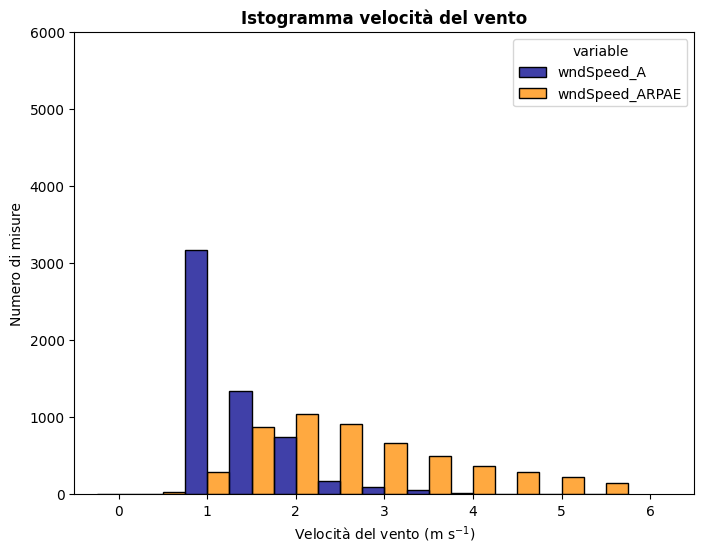

In [43]:
df_merged

fig_hist = plt.figure(figsize=(8, 6))

bins = np.arange(-0.25,6,0.5)
#display(df_merged[['wndSpeed_A','wndSpeed_ARPAE']].melt())

hist = sns.histplot(data=df_merged[['wndSpeed_A','wndSpeed_ARPAE']].melt(), x='value', hue='variable', bins=bins, 
             multiple='dodge',palette={'wndSpeed_A': 'darkblue', 'wndSpeed_ARPAE': 'darkorange'})

# ISTOGRAMMI delle singole stazioni
#sns.histplot(df_merged['wndSpeed_A'], bins=bins,kde=False, color='blue')
#sns.histplot(df_merged['wndSpeed_ARPAE'], bins=bins,kde=False, color='orange')

plt.title('Istogramma velocità del vento',fontweight='bold')
plt.xlabel("Velocità del vento (m s$^{-1}$)")
plt.ylabel("Numero di misure")
plt.ylim(0,6000)
plt.xlim(-0.5,6.5)

legend = hist.get_legend()
handles = legend.legendHandles
legend.remove()
plt.legend(handles, ['Stazione A', 'Stazione ARPAE'])

plt.tight_layout()
plt.show()